In [124]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

import smarts_cerebellum.globals as gl

In [125]:
all_rois = (['Left_I_IV', 'Right_I_IV', 'Left_V', 'Right_V', 'Left_VI',
       'Vermis_VI', 'Right_VI', 'Left_CrusI', 'Vermis_CrusI',
       'Right_CrusI', 'Left_CrusII', 'Vermis_CrusII', 'Right_CrusII',
       'Left_VIIb', 'Vermis_VIIb', 'Right_VIIb', 'Left_VIIIa',
       'Vermis_VIIIa', 'Right_VIIIa', 'Left_VIIIb', 'Vermis_VIIIb',
       'Right_VIIIb', 'Left_IX', 'Vermis_IX', 'Right_IX', 'Left_X',
       'Vermis_X', 'Right_X', 'Left_Dentate', 'Right_Dentate',
       'Left_Interposed', 'Right_Interposed', 'Left_Fastigial',
       'Right_Fastigial'])

In [126]:
segment = 'GM'
df = pd.read_csv(os.path.join(gl.baseDir, 'anatomicals', f'summary__Diedrichsen_2009_{segment}.tsv'), sep = '\t')


# get regionnames (if df has "region i" instead of name)
region_nums = [f'region {i+1}' for i in range(34)]
name_dict = dict(zip(region_nums, all_rois))
df['regionname'] = df['regionname'].map(name_dict)

df['hemisphere'] = df.regionname.str[0]

regions = ['Left_CrusI', 'Vermis_CrusI',
       'Right_CrusI', 'Left_CrusII', 'Vermis_CrusII', 'Right_CrusII',
       ]

df = df[df.regionname.isin(regions)]

# colour palette
reds = sns.color_palette("Reds", n_colors=len(regions)//2-1)
blues = sns.color_palette("Blues", n_colors=len(regions)//2-1)


In [127]:
df[df.isPatient == 0].subj_id.unique()

array(['CUP_1001', 'JHP_1001', 'JHP_1002', 'UZP_1001', 'UZP_1002',
       'UZP_1004', 'UZP_1005', 'UZP_1006', 'UZP_1007', 'UZP_1008'],
      dtype=object)

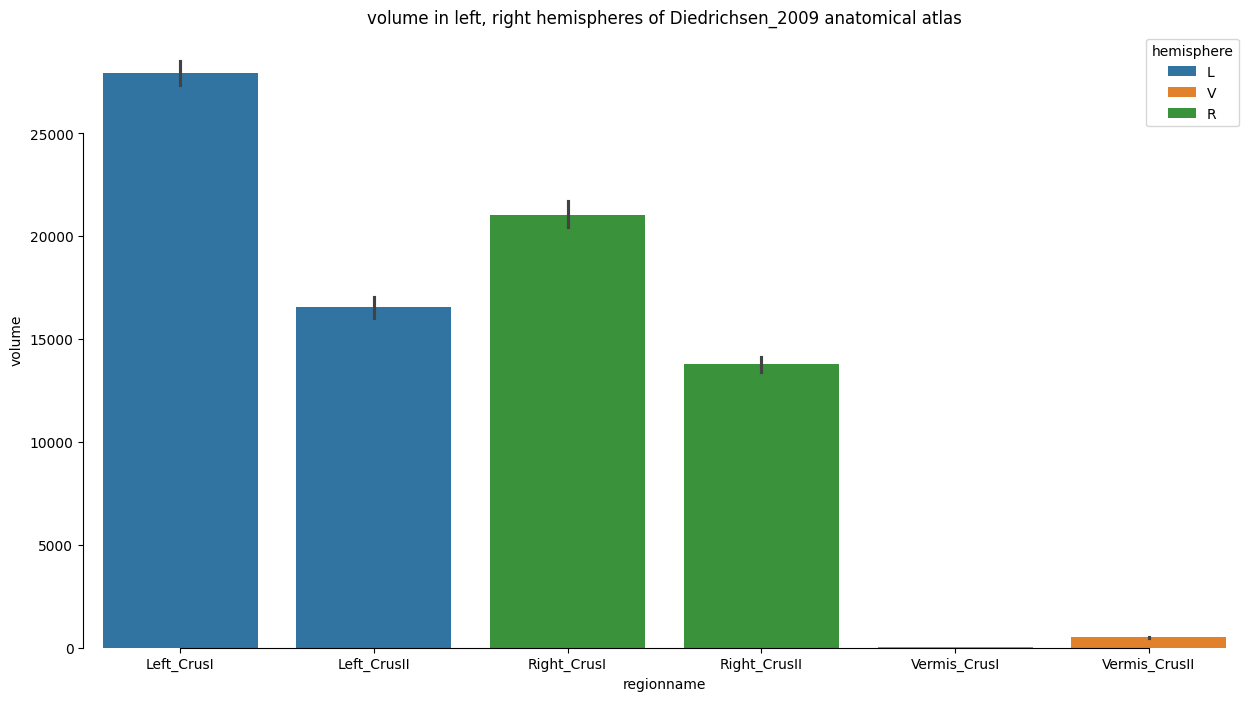

In [136]:
fig, ax = plt.subplots(figsize=(15,8))

region_order = (df[['regionname', 'hemisphere']].sort_values(['hemisphere', 'regionname'])['regionname'].to_list())

vol_df = df
sns.barplot(data = vol_df, x = 'regionname', y = 'volume', hue = 'hemisphere', order = region_order)

plt.title("volume in left, right hemispheres of Diedrichsen_2009 anatomical atlas")
sns.despine(trim = True)
plt.show()

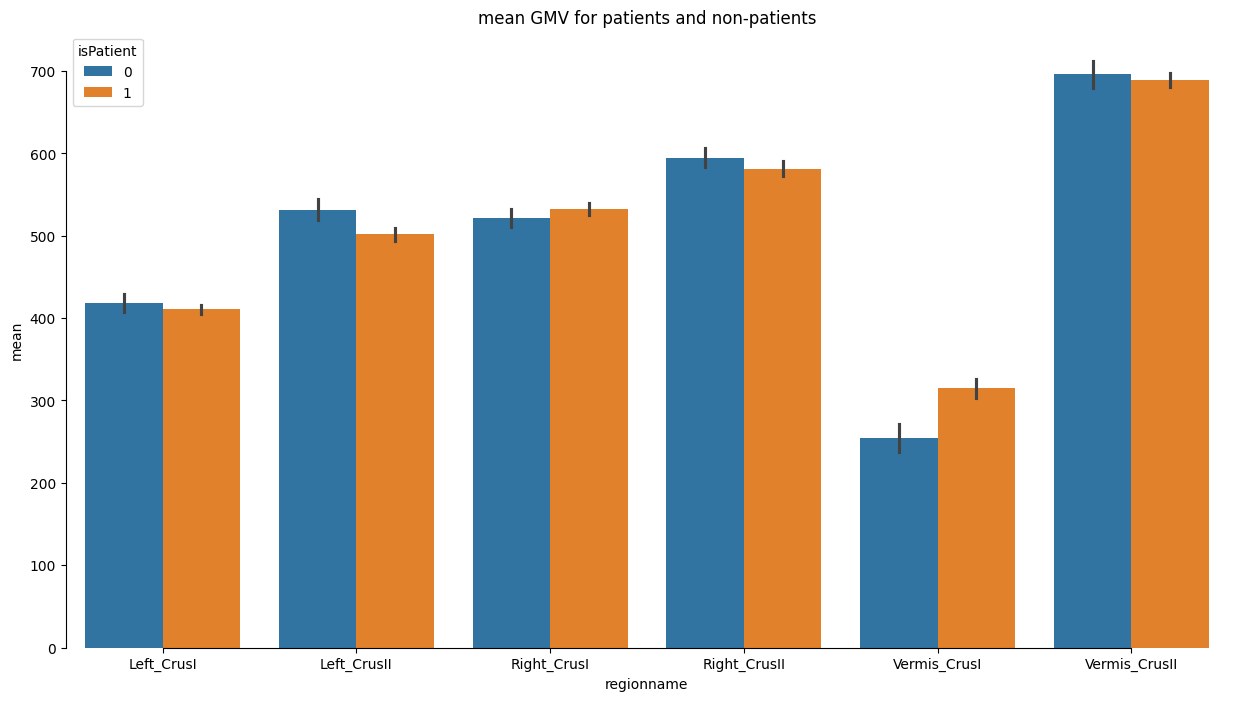

In [138]:
fig, ax = plt.subplots(figsize=(15,8))

region_order = (df[['regionname', 'hemisphere']].sort_values(['hemisphere', 'regionname'])['regionname'].to_list())

vol_df = df
sns.barplot(data = vol_df, x = 'regionname', y = 'mean', hue = 'isPatient', order = region_order, errorbar = 'se')

plt.title("mean GMV for patients and non-patients")
sns.despine(trim = True)
plt.show()

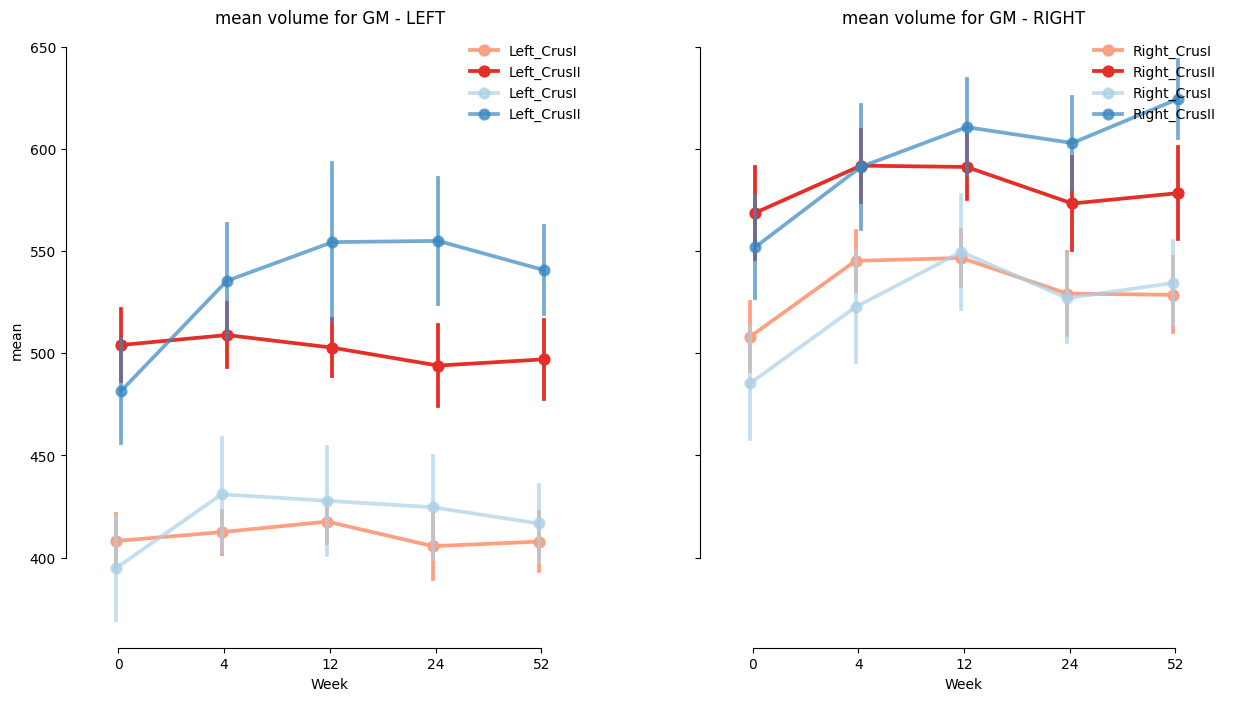

In [129]:
fig, ax = plt.subplots(1, 2, figsize=(15,8), sharey = True)

# left hemisphere

left_patients = df[(df.isPatient == 1) & (df.hemisphere == 'L')]
left_controls = df[(df.isPatient == 0) & (df.hemisphere == 'L')]

sns.pointplot(data = left_patients, x = 'Week', y = 'mean', estimator = 'mean', errorbar = 'se', hue = 'regionname', palette = reds, ax = ax[0], dodge = True)
sns.pointplot(data = left_controls, x = 'Week', y = 'mean', estimator = 'mean', errorbar = 'se', hue = 'regionname', palette = blues, ax = ax[0], alpha = .7, dodge = True)

ax[0].set_title(f'mean volume for {segment} - LEFT')
ax[0].legend(bbox_to_anchor = (1,1), loc = 'upper right', frameon = False)

# right hemisphere

right_patients = df[(df.isPatient == 1) & (df.hemisphere == 'R')]
right_controls = df[(df.isPatient == 0) & (df.hemisphere == 'R')]

sns.pointplot(data = right_patients, x = 'Week', y = 'mean', estimator = 'mean', errorbar = 'se', hue = 'regionname', palette = reds, ax = ax[1], dodge = True)
sns.pointplot(data = right_controls, x = 'Week', y = 'mean', estimator = 'mean', errorbar = 'se', hue = 'regionname', palette = blues, ax = ax[1], alpha = .7, dodge = True)

ax[1].set_title(f'mean volume for {segment} - RIGHT')
ax[1].legend(bbox_to_anchor = (1,1), loc = 'upper right', frameon = False)


    
sns.despine(trim = True)
plt.show()